# 🔄 Lesson 08 · 迭代优化工作流（循环）

> **图上的 while**：生成 → 评估 → 未通过则优化再评估，直到通过或达上限。

本课你会学到：
- 用回环边代替 Python `while`
- 路由函数读 `evaluation` / 迭代计数
- 迭代状态如何写入并回传图

模型：**DeepSeek V4 Pro**（`deepseek-v4-pro`）。`.env` 需配置 `DEEPSEEK_API_KEY`（可选 `DEEPSEEK_BASE_URL`）。


## 逻辑总览

```mermaid
%%{init: {
  "theme": "base",
  "themeVariables": {
    "fontSize": "13px",
    "fontFamily": "ui-sans-serif, system-ui",
    "primaryTextColor": "#0f172a",
    "lineColor": "#94a3b8"
  }
}}%%
flowchart TB
    S([START]) --> G[generate]
    G --> EV[evaluate]
    EV --> R{route_evaluation}
    R -->|approved| E([END])
    R -->|needs_improvement| OP[optimize]
    OP --> EV


    classDef input fill:#BFDBFE,stroke:#3B82F6,color:#1E3A8A,stroke-width:2px
    classDef llm fill:#FED7AA,stroke:#F97316,color:#9A3412,stroke-width:2px
    classDef branch fill:#E9D5FF,stroke:#A855F7,color:#6B21A8,stroke-width:2px
    classDef tool fill:#BBF7D0,stroke:#22C55E,color:#14532D,stroke-width:2px
    classDef output fill:#FECACA,stroke:#F87171,color:#7F1D1D,stroke-width:2px
    class S input
    class G,EV,OP llm
    class R branch
    class E output
```


**要点：** 图上的回环替代 Python `while`；路由读 `evaluation` / 迭代计数。



# Imports


In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import operator
from dotenv import load_dotenv

C:\Users\86137\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\triton\windows_utils.py:372: UserWarning: Failed to find CUDA.
  warnings.warn("Failed to find CUDA.")


# 加载环境变量


In [2]:
load_dotenv()

True

# 定义 LLM

生成器与评估器可共用或分开模型。


In [3]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL", "https://api.deepseek.com")

_llm_kwargs = dict(
    model="deepseek-v4-pro",
    temperature=0,
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    timeout=120,
    max_tokens=1200,
    max_retries=1,
    extra_body={"thinking": {"type": "disabled"}},
)

generator_llm = ChatOpenAI(**_llm_kwargs)
evaluator_llm = ChatOpenAI(**_llm_kwargs)
optimizer_llm = ChatOpenAI(**_llm_kwargs)



# Schema — PostEvaluation

评估结果：`approved` 或 `needs_improvement`。


In [4]:
from pydantic import BaseModel, Field

class PostEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the Facebook post.")

# 绑定 Structured Evaluator


In [5]:
structured_evaluator_llm = evaluator_llm.with_structured_output(PostEvaluation, method="function_calling")

In [6]:
post = """
🚀 The future of AI is no longer just about answering questions — it’s about taking action.

Welcome to the era of *Agentic AI* 🤖

Agentic AI systems can plan, reason, make decisions, and execute tasks autonomously. From managing workflows and analyzing data to coordinating tools and solving complex problems, these AI agents are transforming how we work and innovate.

Imagine an AI that doesn’t just assist you — it collaborates with you.

🔹 Smarter automation
🔹 Faster decision-making
🔹 Personalized experiences
🔹 Continuous learning & adaptation

Businesses, developers, and creators who embrace Agentic AI early will shape the next generation of digital transformation.

The question is no longer *“Can AI do this?”*
It’s *“How far can AI agents go?”*

#AgenticAI #ArtificialIntelligence #AI #Automation #FutureOfWork #Innovation #TechTrends #GenerativeAI

"""


result = structured_evaluator_llm.invoke(post)

In [7]:
result.evaluation

'approved'

In [8]:
result.feedback

"Great post! It's engaging, forward-looking, and clearly explains the shift from assistive AI to agentic AI. The structure is easy to read, and the hashtags are well-chosen. One small suggestion: consider adding a concrete example or a brief use case to make the concept even more tangible for readers who are new to the topic."

# 定义 State

`PostState` 保存主题、草稿、评估结果与迭代计数。


In [9]:
# state
class PostState(TypedDict):

    topic: str
    post: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    post_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

# Node — generate_post

根据主题生成首版内容。


In [10]:
def generate_post(state: PostState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Facebook influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious Facebook post on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 500 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'post': response, 'post_history': [response]}

# Node — evaluate_post

结构化评估当前草稿。


In [11]:
def evaluate_post(state: PostState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Facebook critic. You evaluate posts based on humor, originality, virality, and post format."),
    HumanMessage(content=f"""
Evaluate the following Facebook post:

Post: "{state['post']}"

Use the criteria below to evaluate the post:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people share, react, or comment on it?  
5. Format – Is it a well-formed Facebook post (not a setup-punchline joke, not a Q&A joke, and under 500 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 500 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

# Node — optimize_post

按反馈改写，迭代计数 +1。


In [12]:
def optimize_post(state: PostState):

    messages = [
        SystemMessage(content="You punch up Facebook posts for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the Facebook post based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Post:
{state['post']}

Re-write it as a short, viral-worthy Facebook post. Avoid Q&A style and stay under 500 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'post': response, 'iteration': iteration, 'post_history': [response]}

# 条件路由 — route_evaluation

通过则 END；否则回 optimize（注意最大迭代）。


In [13]:
def route_evaluation(state: PostState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

# 定义与编译图

关键：`optimize_post → evaluate_post` 形成回环。


In [14]:
graph = StateGraph(PostState)

# add nodes
graph.add_node('generate', generate_post)
graph.add_node('evaluate', evaluate_post)
graph.add_node('optimize', optimize_post)


# add edges
graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate',route_evaluation,{'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

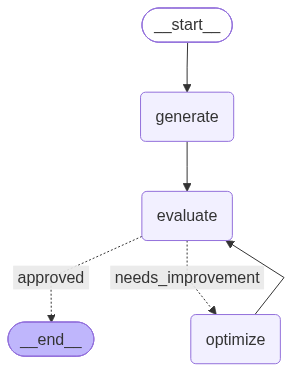

In [15]:
workflow

# 执行工作流


In [16]:
initial_state = {
    "topic": "智能体工作流",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [17]:
result

{'topic': '智能体工作流',
 'post': '我老板最近迷上了“智能体工作流”，说以后不用开会了，AI自动把活干了。结果现在我的日常是：早上和三个智能体吵架，因为它们互相觉得对方生成的文档是垃圾。中午我手动改了80%的AI产出。下午老板问我为什么效率没提升，我说因为我在给机器人当调解员，这工作流确实智能，就是费人。',
 'evaluation': 'approved',
 'feedback': 'This post is sharp, original, and genuinely funny. The premise — AI agents fighting over each other\'s documents while the human plays mediator — is a fresh, satirical take on the "AI will replace us" trope that hasn\'t been done to death. The escalation from "no more meetings" to "I\'m a robot mediator" lands perfectly, and the closing line "这工作流确实智能，就是费人" is a killer punch — concise, ironic, and very quotable. The post is well under 500 characters, reads naturally as a Facebook rant, and avoids any setup-punchline or Q&A format. It has strong virality potential because it taps into a relatable workplace frustration with a clever twist that people will want to share. No notes.',
 'iteration': 1,
 'max_iteration': 5,
 'post_history': ['我老板最近迷上了“智能体工作流”，说以后不用开会了，AI自动把活干了。结果现在我的日常是：

In [18]:
for post in result['feedback_history']:
    print(post)

This post is sharp, original, and genuinely funny. The premise — AI agents fighting over each other's documents while the human plays mediator — is a fresh, satirical take on the "AI will replace us" trope that hasn't been done to death. The escalation from "no more meetings" to "I'm a robot mediator" lands perfectly, and the closing line "这工作流确实智能，就是费人" is a killer punch — concise, ironic, and very quotable. The post is well under 500 characters, reads naturally as a Facebook rant, and avoids any setup-punchline or Q&A format. It has strong virality potential because it taps into a relatable workplace frustration with a clever twist that people will want to share. No notes.
